In [ ]:
# sudo apt install python3-venv
# python3 -m venv myenv
# source myenv/bin/activate
# pip install notebook
# jupyter notebook
# pip install tensorflow keras pandas numpy scikit-learn matplotlib seaborn

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Epoch 1/5


C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7377 - loss: 0.4990 - val_accuracy: 0.8316 - val_loss: 0.3827
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9006 - loss: 0.2498 - val_accuracy: 0.8770 - val_loss: 0.2929
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9166 - loss: 0.2110 - val_accuracy: 0.8815 - val_loss: 0.2887
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9263 - loss: 0.1919 - val_accuracy: 0.8802 - val_loss: 0.3003
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9390 - loss: 0.1694 - val_accuracy: 0.8750 - val_loss: 0.3425
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8729 - loss: 0.3334
Test Accuracy: 0.8730000257492065
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.82      0.86      4961
           1       0.84      0.93      0.88      5039

    accuracy         

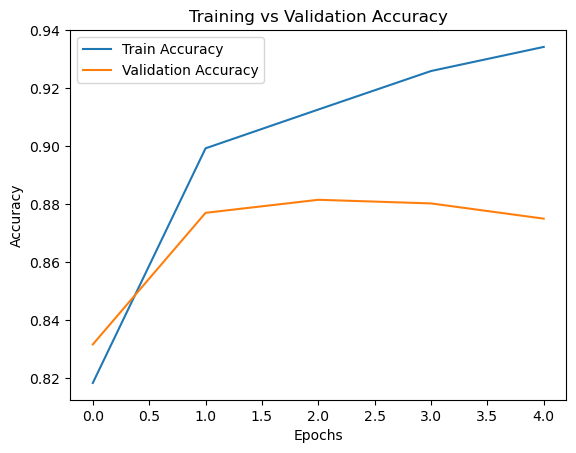

In [14]:
# IMDB Sentiment Analysis (Binary Classification using DNN)

import pandas as pd

# ==============================
# 1. LOAD DATASET
# ==============================
data = pd.read_csv("imdb.csv")  
print(data.head())

# ==============================
# 2. LABEL CONVERSION
# ==============================
data["sentiment"] = data["sentiment"].map({
    "positive": 1,
    "negative": 0
})

# ==============================
# 3. TEXT PREPROCESSING
# ==============================
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenization
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(data["review"])

sequences = tokenizer.texts_to_sequences(data["review"])

# Padding
X = pad_sequences(sequences, maxlen=200)
y = data["sentiment"].values

# ==============================
# 4. TRAIN-TEST SPLIT
# ==============================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 5. BUILD MODEL (DNN)
# ==============================
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Embedding(10000, 128, input_length=200),

    # Simple and effective layer for DNN
    layers.GlobalAveragePooling1D(),

    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# ==============================
# 6. COMPILE MODEL
# ==============================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==============================
# 7. TRAIN MODEL
# ==============================
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# ==============================
# 8. EVALUATE MODEL
# ==============================
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# ==============================
# 9. PREDICTIONS
# ==============================
predictions = model.predict(X_test)

# Convert probabilities → class labels
predicted_labels = (predictions > 0.5).astype(int)

# ==============================
# 10. CLASSIFICATION REPORT
# ==============================
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, predicted_labels))


import matplotlib.pyplot as plt

# ==============================
# ACCURACY GRAPH
# ==============================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [15]:


# ## 1. Importing Required Library

# ```python
# import pandas as pd
# ```

# * `pandas`  is used for data handling and analysis.
# * `pd` is an alias for easier usage.

# ---

# ## 2. Loading Dataset

# ```python
# data = pd.read_csv("imdb.csv")
# print(data.head())
# ```

# * `read_csv()` loads the dataset file into a DataFrame.
# * `data` stores the dataset.
# * `head()` displays the first 5 rows to verify the data.

# ---

# ## 3. Label Conversion (Text to Numeric)

# ```python
# data["sentiment"] = data["sentiment"].map({
#     "positive": 1,
#     "negative": 0
# })
# ```

# * Converts categorical labels into numerical form.
# * Positive is mapped to 1 and negative to 0.
# * Required because machine learning models work with numbers.

# ---

# ## 4. Text Preprocessing

# ```python
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences
# ```

# * `Tokenizer` converts text into numerical tokens.
# * `pad_sequences` ensures all sequences have equal length.

# ---

# ### Tokenization

# ```python
# tokenizer = Tokenizer(num_words=10000)
# tokenizer.fit_on_texts(data["review"])
# ```

# * Keeps the top 10,000 most frequent words.
# * Learns vocabulary from the dataset.

# ```python
# sequences = tokenizer.texts_to_sequences(data["review"])
# ```

# * Converts each review into a sequence of integers.

# ---

# ### Padding

# ```python
# X = pad_sequences(sequences, maxlen=200)
# ```

# * Ensures each review has length 200.
# * Short reviews are padded with zeros.
# * Long reviews are truncated.

# ```python
# y = data["sentiment"].values
# ```

# * Stores the target labels (0 or 1).

# ---

# ## 5. Train-Test Split

# ```python
# from sklearn.model_selection import train_test_split
# ```

# * Used to split data into training and testing sets.

# ```python
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )
# ```

# * 80% data is used for training and 20% for testing.
# * `random_state=42` ensures consistent results.

# ---

# ## 6. Building Deep Neural Network (DNN)

# ```python
# from tensorflow import keras
# from tensorflow.keras import layers
# ```

# * Imports Keras and layer components.

# ```python
# model = keras.Sequential([
# ```

# * Creates a sequential model where layers are added one after another.

# ```python
#     layers.Embedding(10000, 128, input_length=200),
# ```

# * Converts words into dense vectors.
# * Vocabulary size is 10,000.
# * Each word is represented using 128 dimensions.
# * Input length is 200.

# ```python
#     layers.GlobalAveragePooling1D(),
# ```

# * Reduces sequence into a single vector by averaging.
# * Helps reduce complexity.

# ```python
#     layers.Dense(64, activation='relu'),
# ```

# * Fully connected layer with 64 neurons.
# * Uses ReLU activation for non-linearity.

# ```python
#     layers.Dense(1, activation='sigmoid')
# ])
# ```

# * Output layer with 1 neuron.
# * Sigmoid activation gives output between 0 and 1.

# ---

# ## 7. Compiling Model

# ```python
# model.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )
# ```

# * `adam` is used to update weights.
# * `binary_crossentropy` is used for binary classification.
# * `accuracy` measures performance.

# ---

# ## 8. Training Model

# ```python
# history = model.fit(
#     X_train, y_train,
#     epochs=5,
#     batch_size=32,
#     validation_split=0.2
# )
# ```

# * Trains the model on training data.
# * `epochs=5` means training is repeated 5 times.
# * `batch_size=32` processes 32 samples at a time.
# * `validation_split=0.2` uses 20% of training data for validation.

# ---

# ## 9. Model Evaluation

# ```python
# loss, accuracy = model.evaluate(X_test, y_test)
# print("Test Accuracy:", accuracy)
# ```

# * Evaluates model performance on test data.
# * Prints accuracy.

# ---

# ## 10. Predictions

# ```python
# predictions = model.predict(X_test)
# ```

# * Generates probability predictions.

# ```python
# predicted_labels = (predictions > 0.5).astype(int)
# ```

# * Converts probabilities into class labels.
# * Values greater than 0.5 are classified as 1, otherwise 0.

# ---

# ## 11. Classification Report

# ```python
# from sklearn.metrics import classification_report
# ```

# * Used to evaluate classification performance.

# ```python
# print("\nClassification Report:\n")
# print(classification_report(y_test, predicted_labels))
# ```

# * Displays precision, recall, F1-score, and accuracy.

# ---

# ## 12. Plotting Accuracy Graph

# ```python
# import matplotlib.pyplot as plt
# ```

# * Used for visualization.

# ```python
# plt.plot(history.history['accuracy'], label='Train Accuracy')
# plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
# ```

# * Plots training and validation accuracy.

# ```python
# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")
# plt.title("Training vs Validation Accuracy")
# ```

# * Adds labels and title.

# ```python
# plt.legend()
# plt.show()
# ```

